<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/ChurnPredictionANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/credit-card-customer-churn-prediction


In [61]:
import pandas as pd
df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [62]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [63]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [67]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [68]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [69]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [70]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
X_train.shape

(8000, 11)

In [74]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [75]:
model = Sequential()

model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [78]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7731
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6211
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5426
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5034  
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4826
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4696
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4600  
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4523
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4458
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4406  


In [79]:
model.layers[0].get_weights()

[array([[ 4.58757654e-02,  3.98852438e-01,  1.45167664e-01],
        [ 1.11084807e+00, -6.62354231e-01, -2.21503782e+00],
        [-1.99938953e-01, -2.58939326e-01,  1.17183805e-01],
        [ 3.55246961e-01, -5.04172146e-01, -2.39818007e-01],
        [-4.18251097e-01, -2.04304427e-01,  2.70403892e-01],
        [-2.09479570e-01, -2.23810822e-01,  1.67170179e-03],
        [-1.06418192e+00,  6.68693602e-01,  5.94913006e-01],
        [ 2.95729518e-01,  3.17987710e-01, -2.04259083e-02],
        [ 9.55114603e-01, -1.02226973e+00, -5.30600190e-01],
        [ 2.54364938e-01,  1.44034952e-01, -6.10269904e-02],
        [-1.09119691e-01,  6.63493514e-01,  5.69213867e-01]], dtype=float32),
 array([-0.5103249 ,  0.12385555,  0.77768195], dtype=float32)]

In [80]:
y_log = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [81]:
import numpy as np
y_pred = np.where(y_log>0.5,1,0)
from sklearn.metrics import accuracy_score

In [82]:
accuracy_score(y_test , y_pred)

0.8035

In [83]:
#to increase accuracy -> try to increase layers, nodes in hidden layers,

In [84]:
model2 = Sequential()

model2.add(Dense(11,activation='relu',input_dim=11))
model2.add(Dense(11,activation='relu'))
model2.add(Dense(1,activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model2.compile(loss='binary_crossentropy',optimizer='Adam')

In [87]:
history = model2.fit(X_train,y_train,epochs=20,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3380 - val_loss: 1.5472
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3740 - val_loss: 1.1384
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1189 - val_loss: 0.9181
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9723 - val_loss: 0.9002
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9177 - val_loss: 0.7990
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7820 - val_loss: 0.6636
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6909 - val_loss: 0.6461
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6411 - val_loss: 0.6085
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6042 - val_loss: 0.5913
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6029 - val_loss: 0.6004
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5858 - val_loss: 0.5757
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [88]:
y_log2 = model2.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [89]:
y_pred2 = np.where(y_log2>0.5,1,0)

In [90]:
accuracy_score(y_test,y_pred2)

0.8045

In [91]:
import matplotlib.pyplot as plt
history.history

{'loss': [2.33803391456604,
  1.3740195035934448,
  1.1188818216323853,
  0.9722824692726135,
  0.917725682258606,
  0.7820003032684326,
  0.690886378288269,
  0.6411088705062866,
  0.6041785478591919,
  0.6029472351074219,
  0.5858469605445862,
  0.5674320459365845,
  0.652539074420929,
  0.576172947883606,
  0.5674580335617065,
  0.5549290180206299,
  0.5305443406105042,
  0.524025559425354,
  0.5170765519142151,
  0.5106310844421387],
 'val_loss': [1.547226905822754,
  1.1384491920471191,
  0.9180636405944824,
  0.9002012014389038,
  0.7990193367004395,
  0.6636108160018921,
  0.646141767501831,
  0.6084995865821838,
  0.5912594199180603,
  0.6003820300102234,
  0.5757343173027039,
  0.7362689971923828,
  0.6184044480323792,
  0.573422372341156,
  0.5803577899932861,
  0.5483688116073608,
  0.5538281798362732,
  0.5596411824226379,
  0.5419838428497314,
  0.529507577419281]}

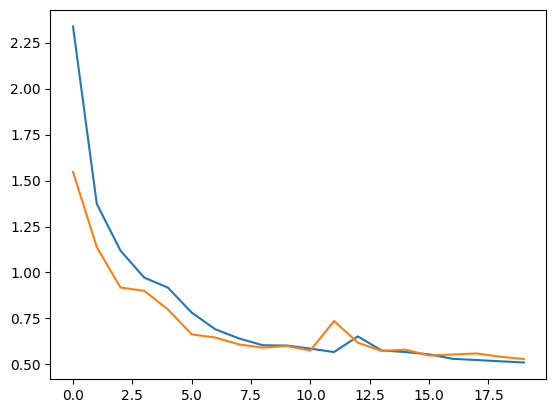

In [92]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])